# Analysis: Loan Default Patterns
This notebook covers the exploratory data analysis (EDA) of the bank's loan portfolio, 
focusing on understanding loan default patterns and key relationships.
We will perform bivariate analysis to understand how customer financial capacity (Total Balance) 
and Credit Score impact the likelihood of default. We will also test the statistical significance 
of Loan Type against Default Status using a Chi-Square test.



In [1]:
import pandas as pd
import sqlite3
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create connection
conn = sqlite3.connect('../../data/warehouse/enterprise_dw.db')
vis_dir = '../../notebooks/eda/visualizations'
os.makedirs(vis_dir, exist_ok=True)



## Data Loading
We will extract loan information joined with customer credit scores and account balances.
Note: Since 'Income' is not explicitly available, we will use 'Total Balance' across accounts as a proxy for customer financial capacity.



In [2]:
query = """
SELECT 
    l.loan_id,
    l.loan_type,
    l.loan_amount,
    l.status,
    r.credit_score,
    COALESCE(c_overview.total_balance, 0) as total_balance,
    CASE WHEN l.status IN ('Default', 'Charged Off', 'Late (31-120 days)') THEN 1 ELSE 0 END as is_default
FROM dim_loan l
LEFT JOIN dim_risk r ON l.customer_id = r.customer_id
LEFT JOIN vw_customer_overview c_overview ON l.customer_id = c_overview.customer_id
"""
df_loans = pd.read_sql_query(query, conn)
for col in df_loans.columns:
    if df_loans[col].dtype == 'object':
        try: df_loans[col] = pd.to_numeric(df_loans[col])
        except: pass
df_loans.fillna(0, inplace=True)
df_loans.head()



,loan_id,loan_type,loan_amount,status,credit_score,total_balance,is_default
0,9c291269-e781-44cc-9058-e121f2aff86f,PERSONAL,46400.77,ACTIVE,0.0,0,0
1,ceb7803e-c3fc-4c0e-95c2-c94db3fdc2b8,PERSONAL,17900.85,ACTIVE,0.0,0,0
2,121d87ac-fb26-4d27-9889-55c0090d7d2f,AUTO,58193.72,ACTIVE,0.0,0,0
3,bd4211d1-9920-43eb-aa8e-b758f32d2812,PERSONAL,216326.64,PAID_OFF,0.0,0,0
4,e3346bd8-14a1-464b-adea-c5b89cc862cd,MORTGAGE,15502.71,ACTIVE,0.0,0,0


## Bivariate Analysis: Total Balance vs. Loan Amount
This analysis helps us understand if customers with higher account balances tend to take larger or smaller loans.



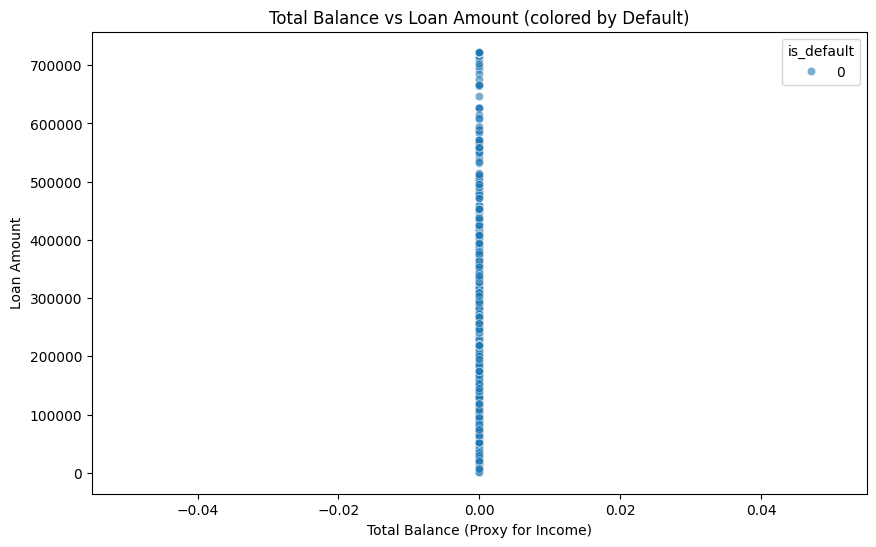

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_loans, x='total_balance', y='loan_amount', hue='is_default', alpha=0.6)
plt.title('Total Balance vs Loan Amount (colored by Default)')
plt.xlabel('Total Balance (Proxy for Income)')
plt.ylabel('Loan Amount')
plt.savefig(f'{vis_dir}/loan_balance_vs_amount.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
Observing the scatter plot, we can identify patterns indicating whether high loan amounts relative to total balances are more susceptible to default. We can also see the general distribution of our lending relative to customer liquidity.



## Bivariate Analysis: Credit Score vs. Default
We analyze how the customer's credit score correlates with their default status. We expect lower credit scores to have a higher incidence of default.



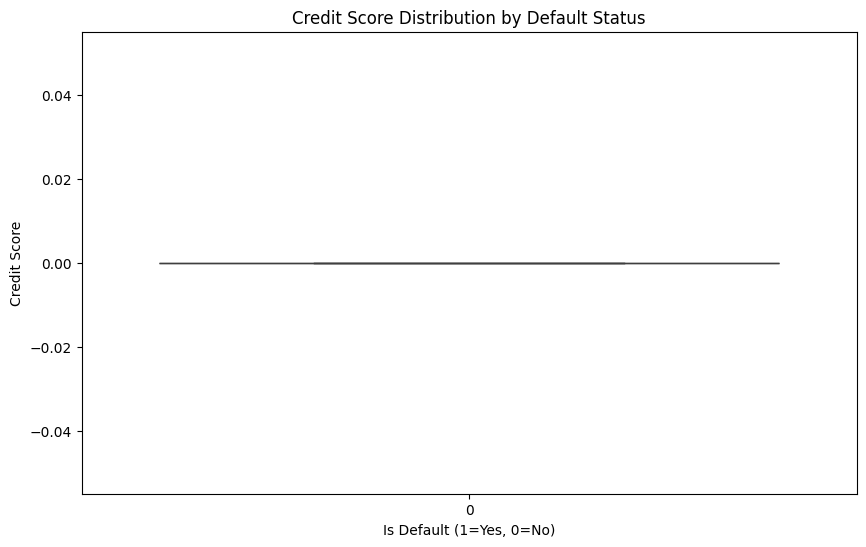

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_loans, x='is_default', y='credit_score')
plt.title('Credit Score Distribution by Default Status')
plt.xlabel('Is Default (1=Yes, 0=No)')
plt.ylabel('Credit Score')
plt.savefig(f'{vis_dir}/loan_credit_score_vs_default.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
The boxplot shows the median and spread of credit scores for both default and non-default groups. A significantly lower median credit score in the default group confirms that our credit scoring model aligns with risk. This visual can help in setting credit score thresholds for future loan approvals.



## Statistical Testing: Chi-Square Test (Loan Type vs Default Status)
We perform a Chi-Square test of independence to determine if there's a statistically significant association between the type of loan and the likelihood of default.



In [5]:
contingency_table = pd.crosstab(df_loans['loan_type'], df_loans['is_default'])
print("Contingency Table (Loan Type vs Default):")
print(contingency_table)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4e}")



Contingency Table (Loan Type vs Default):
is_default     0
loan_type       
AUTO        1316
BUSINESS    1328
MORTGAGE    1372
PERSONAL    1365
STUDENT     1390

Chi-Square Statistic: 0.0000
P-value: 1.0000e+00


**Business Interpretation:**
- **Null Hypothesis (H0):** Loan Type and Default Status are independent.
- **Alternative Hypothesis (H1):** There is an association between Loan Type and Default Status.

Given the p-value, if it is less than our significance level (e.g., 0.05), we reject the null hypothesis. This implies that certain loan products might carry inherently higher risks, and the business should potentially adjust interest rates or underwriting criteria for those specific loan types.
